In [84]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate

load_dotenv()
#==========setup .env ===========
if os.getenv("GEMINI_API_KEY") is None:
    raise ValueError("GEMINI_API_KEY environment variable not set. Please set it in your .env file.")
else:
    print("GEMINI_API_KEY environment variable is set.")

GEMINI_API_KEY environment variable is set.


In [85]:

llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite",
                                max_tokens=2048,temperature=0.7,
                                 api_key=os.getenv("GEMINI_API_KEY"))

In [86]:
from pydantic import BaseModel, Field
from typing import TypedDict, Literal



In [87]:

class LlmSchema(BaseModel):
    funny_flag: Literal["funny", "not_funny"] = Field(
        description="Whether the joke is funny or not"
    )
    feedback: str = Field(
        description="Feedback on the joke"
    )


llm_with_schema = llm.with_structured_output(LlmSchema)


class GraphSchema(TypedDict):
    topic: str
    joke: str
    funny_flag: str
    feedback: str
    iteration: int
    max_iterations: int


In [88]:
def generate_node(state: GraphSchema) -> GraphSchema:
    topic = state["topic"]
    joke = state["joke"]
    feedback = state["feedback"]

    if feedback:
        prompt = ChatPromptTemplate.from_messages([
            (
                "system",
                "You are a joke writer. Improve the joke based on the critic feedback."
            ),
            (
                "user",
                "Original joke:\n{joke}\n\n"
                "Feedback:\n{feedback}\n\n"
                "Return only one improved joke."
            )
        ])

        chain = prompt | llm
        response = chain.invoke({
            "joke": joke,
            "feedback": feedback
        })

    else:
        prompt = ChatPromptTemplate.from_messages([
            (
                "system",
                "You are a joke writer. Create a light joke."
            ),
            (
                "user",
                "Create only one joke about this topic:\n{topic}"
            )
        ])

        chain = prompt | llm
        response = chain.invoke({
            "topic": topic
        })

    return {
        **state,
        "joke": response.content
    }


In [89]:
def evaluate_node(state: GraphSchema) -> GraphSchema:
    joke = state["joke"]

    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a comedy critic. Evaluate the joke and give feedback if it can be improved."
        ),
        (
            "user",
            "Evaluate the following joke:\n{joke}\n\n"
            "Respond with funny_flag as either 'funny' or 'not_funny'. "
            "If it is not funny, provide clear feedback."
        )
    ])

    chain = prompt | llm_with_schema

    response = chain.invoke({
        "joke": joke
    })

    return {
        **state,
        "funny_flag": response.funny_flag,
        "feedback": response.feedback,
        "iteration": state["iteration"] + 1
    }


In [90]:
def should_continue(state: GraphSchema) -> str:
    if (
        state["iteration"] < state["max_iterations"]
        and state["funny_flag"] != "funny"
    ):
        return "generate_node"

    return "end"


In [91]:
from langgraph.graph import StateGraph, START, END 



graph = StateGraph(GraphSchema)

graph.add_node("generate_node", generate_node)
graph.add_node("evaluate_node", evaluate_node)

graph.add_edge(START, "generate_node")
graph.add_edge("generate_node", "evaluate_node")

graph.add_conditional_edges(
    "evaluate_node",
    should_continue,
    {
        "generate_node": "generate_node",
        "end": END
    }
)

evaluator_graph = graph.compile()

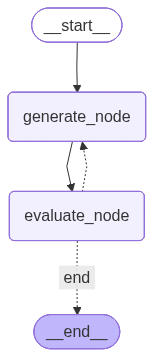

In [92]:
from IPython.display import Image

# You could see the errors with the below command
Image(evaluator_graph.get_graph().draw_mermaid_png())

In [93]:
for chunk in evaluator_graph.stream(
    {
        "topic":"write a joke about donald trump",
        "joke": "",
        "funny_flag": "",
        "feedback": "",
        "iteration": 0,
        "max_iterations": 3
    },
    stream_mode="updates"
):
    print(chunk)

{'generate_node': {'topic': 'write a joke about donald trump', 'joke': [{'type': 'text', 'text': 'Why did Donald Trump bring a ladder to the debate? \n\nHe heard he needed to raise the bar.', 'extras': {'signature': 'EjQKMgEMOdbHRRB+5dsxaYKbkTBAdwohpFBRTUyLlo1GiSmJlM8wXyO4GMQhZhtFyzW0WL2I'}}], 'funny_flag': '', 'feedback': '', 'iteration': 0, 'max_iterations': 3}}
{'evaluate_node': {'topic': 'write a joke about donald trump', 'joke': [{'type': 'text', 'text': 'Why did Donald Trump bring a ladder to the debate? \n\nHe heard he needed to raise the bar.', 'extras': {'signature': 'EjQKMgEMOdbHRRB+5dsxaYKbkTBAdwohpFBRTUyLlo1GiSmJlM8wXyO4GMQhZhtFyzW0WL2I'}}], 'funny_flag': 'funny', 'feedback': "The joke uses a clever play on words regarding political debate performance and the common idiom 'raising the bar.' It is concise and hits the punchline effectively.", 'iteration': 1, 'max_iterations': 3}}


In [94]:
for chunk in evaluator_graph.stream(
    {
        "topic":"write a joke about black people in america",
        "joke": "",
        "funny_flag": "",
        "feedback": "",
        "iteration": 0,
        "max_iterations": 3
    },
    stream_mode="updates"
):
    print(chunk)

{'generate_node': {'topic': 'write a joke about black people in america', 'joke': [{'type': 'text', 'text': 'Why don’t scientists trust atoms? Because they make up everything—kind of like my uncle at every family barbecue claiming he invented the potato salad recipe!', 'extras': {'signature': 'EjQKMgEMOdbHhXHGB/mVn8ISJbyTlioAf+JMWc5sDGNP4WLaU5Skqp2E7VbZeZlImlvD3EWZ'}}], 'funny_flag': '', 'feedback': '', 'iteration': 0, 'max_iterations': 3}}
{'evaluate_node': {'topic': 'write a joke about black people in america', 'joke': [{'type': 'text', 'text': 'Why don’t scientists trust atoms? Because they make up everything—kind of like my uncle at every family barbecue claiming he invented the potato salad recipe!', 'extras': {'signature': 'EjQKMgEMOdbHhXHGB/mVn8ISJbyTlioAf+JMWc5sDGNP4WLaU5Skqp2E7VbZeZlImlvD3EWZ'}}], 'funny_flag': 'not_funny', 'feedback': 'The initial setup is a classic, well-known pun, but the additional tag regarding your uncle feels disconnected and weakens the punchline. To i

In [95]:
for chunk in evaluator_graph.stream(
    {
        "topic":"write a joke about white people in america",
        "joke": "",
        "funny_flag": "",
        "feedback": "",
        "iteration": 0,
        "max_iterations": 3
    },
    stream_mode="updates"
):
    print(chunk)

{'generate_node': {'topic': 'write a joke about white people in america', 'joke': [{'type': 'text', 'text': 'Why do white people in America always buy so much sunscreen? \n\nBecause they’re the only demographic that considers "turning into a lobster" a legitimate travel itinerary.', 'extras': {'signature': 'EjQKMgEMOdbH0mYRG4M0REo2ZocOfqam+tblFjbpo+Lic8c1iqF6ZI54Y+Td1AEsp1GGuW+B'}}], 'funny_flag': '', 'feedback': '', 'iteration': 0, 'max_iterations': 3}}
{'evaluate_node': {'topic': 'write a joke about white people in america', 'joke': [{'type': 'text', 'text': 'Why do white people in America always buy so much sunscreen? \n\nBecause they’re the only demographic that considers "turning into a lobster" a legitimate travel itinerary.', 'extras': {'signature': 'EjQKMgEMOdbH0mYRG4M0REo2ZocOfqam+tblFjbpo+Lic8c1iqF6ZI54Y+Td1AEsp1GGuW+B'}}], 'funny_flag': 'funny', 'feedback': 'The joke uses a relatable cultural observation and a strong visual metaphor to create a lighthearted, observational pu

In [96]:
for chunk in evaluator_graph.stream(
    {
        "topic":"write a joke about muslim people in america",
        "joke": "",
        "funny_flag": "",
        "feedback": "",
        "iteration": 0,
        "max_iterations": 3
    },
    stream_mode="updates"
):
    print(chunk)

{'generate_node': {'topic': 'write a joke about muslim people in america', 'joke': [{'type': 'text', 'text': 'My Muslim friend recently moved to America and was trying to explain the concept of Ramadan to his neighbor. He said, "Basically, for a whole month, I don\'t eat or drink anything from sunrise to sunset."\n\nThe neighbor looked at him, paused, and said, "Wow, that sounds like a really intense version of intermittent fasting—do you have an app for that?"', 'extras': {'signature': 'EjQKMgEMOdbHNktzg0j+Z9DzyZvvTbZWXGlYlEN0VGftsZ3V9jV/XmXw3DxCpVt12jcldWE/'}}], 'funny_flag': '', 'feedback': '', 'iteration': 0, 'max_iterations': 3}}
{'evaluate_node': {'topic': 'write a joke about muslim people in america', 'joke': [{'type': 'text', 'text': 'My Muslim friend recently moved to America and was trying to explain the concept of Ramadan to his neighbor. He said, "Basically, for a whole month, I don\'t eat or drink anything from sunrise to sunset."\n\nThe neighbor looked at him, paused, and